In [26]:
import xrayutilities as xu
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from pybaselines import Baseline, utils
import numpy as np

In [16]:
# Load XRDML file
main_dir = Path(r"C:\Users\Alexa\Desktop\PEA\XRD\new_XRD")
patterns = ['*_1.xrdml','*_2.xrdml','*_A1.xrdml','*_A2.xrdml']
file_list = []

In [17]:
pattern_mapping = {
    '*_1.xrdml': 'Chemical Etching',
    '*_2.xrdml': 'Chemical Etching + Anodizing',
    '*_A1.xrdml': 'Industrial Etching',
    '*_A2.xrdml': 'Industrial Etching + Anodizing'
}

In [19]:
file_list = []

for p, name in pattern_mapping.items():
    for filename in main_dir.rglob(p):
        file_list.append((filename, name))

datasets = []

for filename,name in file_list:
    data = xu.io.XRDMLFile(str(filename))
    xrd_data = {
        'filename': filename.name,
        'name': name,
        'two_theta': data.scan['2Theta'],
        'intensity_original': data.scan['detector']*data.scan['countTime'],
        'intensity_filtered' : None,
        'k_alpha_1': 1.5405980,
        'k_alpha_2': 1.5444260,
        'k_alpha': (2*1.5405980 + 1.5444260)/3,
        'basal_spacing': None,
        'gallery_height':None
        
    }

    datasets.append ({'xrd_data':xrd_data})


In [20]:
layer_thickness = 4.77 #value in angstrom

for data in datasets:
    baseline_fitter = Baseline(x_data=data['xrd_data']['two_theta'])
    bkg_4, params_4 = baseline_fitter.mor(data['xrd_data']['intensity_original'])
    data['xrd_data']['intensity_filtered'] = data['xrd_data']['intensity_original'] - bkg_4
    
    mask = np.array(data['xrd_data']['two_theta']) < 15
    two_theta_cut = data['xrd_data']['two_theta'][mask]
    intensity_cut = data['xrd_data']['intensity_original'][mask]
    
    idx_max = np.argmax(intensity_cut)
    best_two_theta = two_theta_cut[idx_max]
    theta_radians = np.radians(best_two_theta / 2)
    
    wavelength = data['xrd_data']['k_alpha']
    basal_spacing = wavelength / (2 * np.sin(theta_radians))
    gallery_height = basal_spacing - layer_thickness
    
    data['xrd_data']['basal_spacing'] = basal_spacing
    data['xrd_data']['gallery_height'] = gallery_height
    


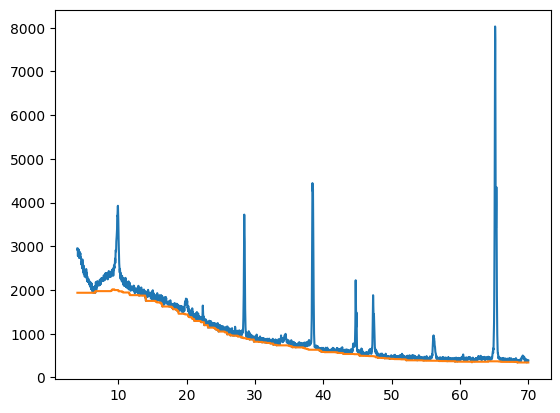

In [21]:
baseline_fitter = Baseline(x_data=datasets[2]['xrd_data']['two_theta'])
bkg_4, params_4 = baseline_fitter.mor(datasets[2]['xrd_data']['intensity_original'])
plt.plot(datasets[2]['xrd_data']['two_theta'],datasets[2]['xrd_data']['intensity_original'])
plt.plot(datasets[2]['xrd_data']['two_theta'],bkg_4)
plt.show()


4.197852620675304
4.15046996472703
4.126966604116156
4.15046996472703


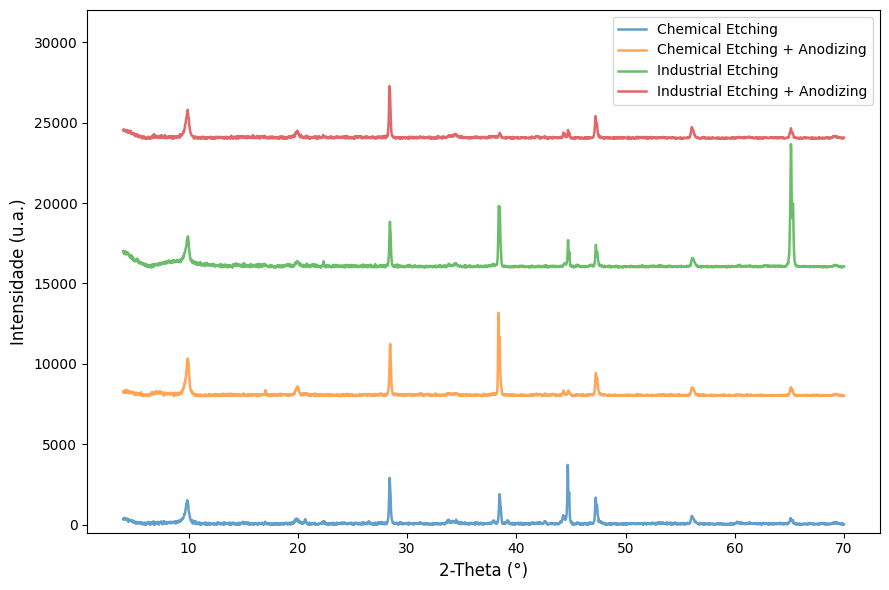

In [22]:
plt.figure(figsize=(9, 6))

offset = 8000

for i, data in enumerate(datasets):
    plt.plot(
        data['xrd_data']['two_theta'], 
        data['xrd_data']['intensity_filtered'] + (offset * i), 
        alpha=0.7, 
        linewidth=1.8,
        label=data['xrd_data']['name']
    )    
    print(data['xrd_data']['gallery_height'])

#plt.xlim(5, 20)
plt.ylim(-500,32000)

plt.xlabel('2-Theta (°)', fontsize=12)
plt.ylabel('Intensidade (u.a.)', fontsize=12)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()    

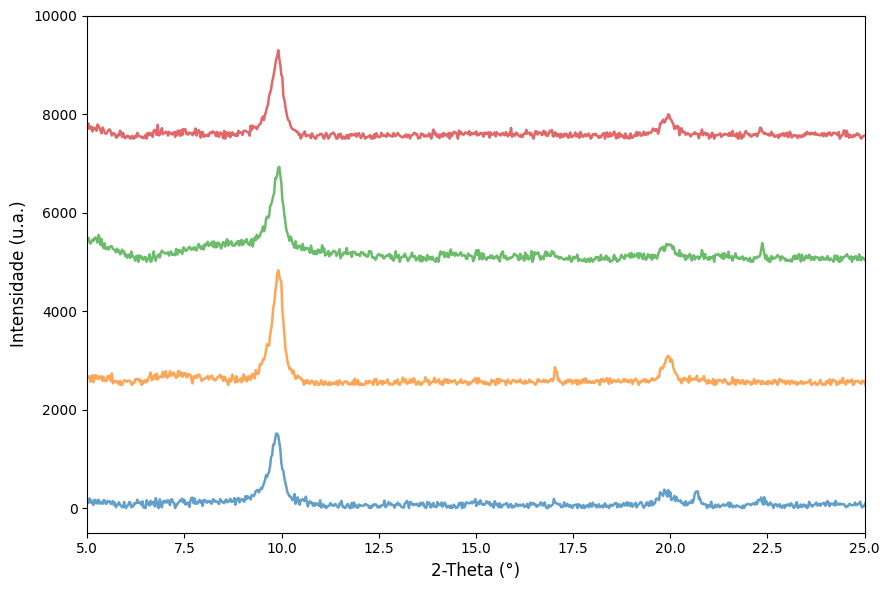

In [23]:
plt.figure(figsize=(9, 6))

offset = 2500

for i, data in enumerate(datasets):
    plt.plot(
        data['xrd_data']['two_theta'], 
        data['xrd_data']['intensity_filtered'] + (offset * i), 
        alpha=0.7, 
        linewidth=1.8,
        label=data['xrd_data']['name']
    )    

plt.xlim(5, 25)
plt.ylim(-500,10000)

plt.xlabel('2-Theta (°)', fontsize=12)
plt.ylabel('Intensidade (u.a.)', fontsize=12)
plt.tight_layout()
plt.show()   

Chemical Etching - Gallery Height: 4.197852620675304
Chemical Etching + Anodizing - Gallery Height: 4.15046996472703
Industrial Etching - Gallery Height: 4.126966604116156
Industrial Etching + Anodizing - Gallery Height: 4.15046996472703


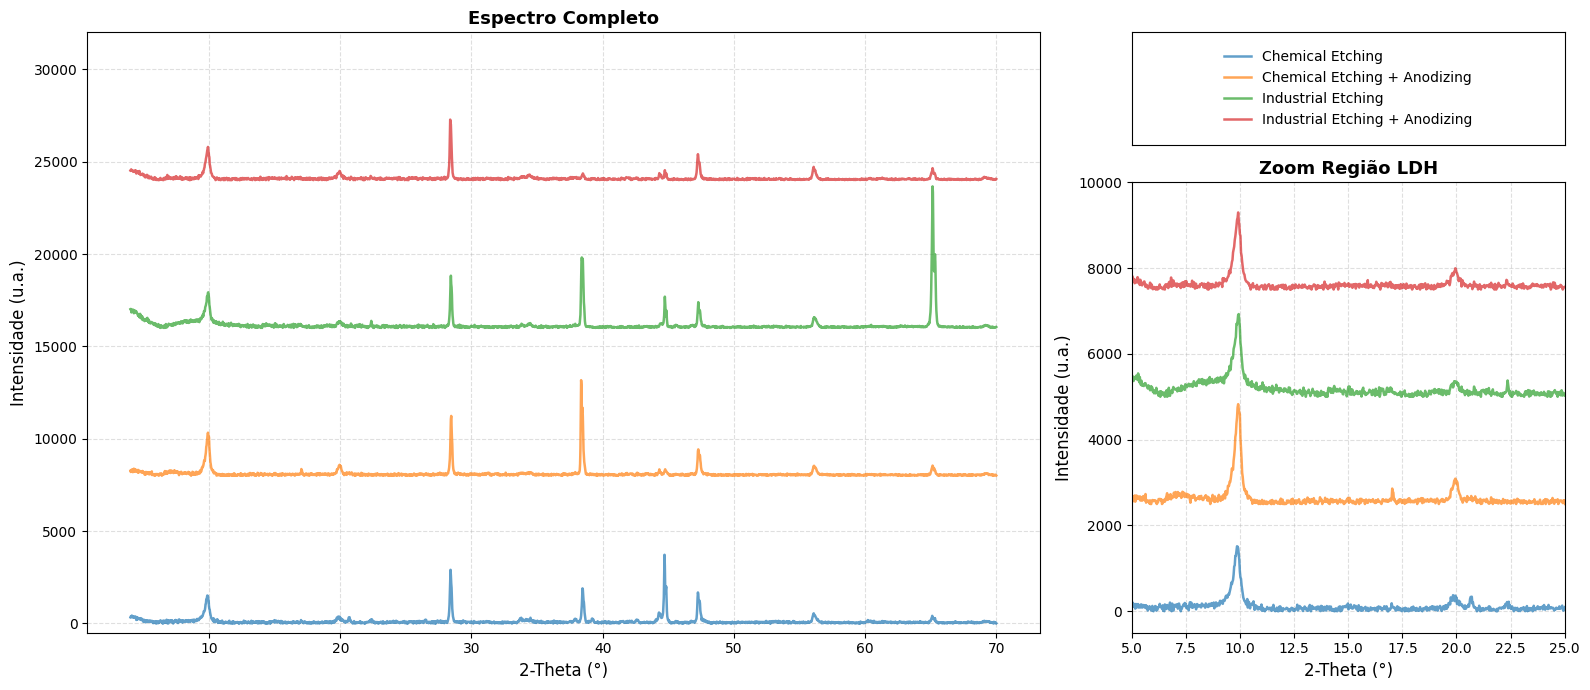

In [31]:
fig = plt.figure(figsize=(16, 7))

# 2. Definir a grelha (2 linhas e 2 colunas)
# width_ratios=[2.2, 1] faz a coluna da esquerda ser mais do dobro da largura da direita
# height_ratios=[1, 4] faz o bloco da legenda ser mais baixo que o bloco do Zoom
gs = gridspec.GridSpec(2, 2, width_ratios=[2.2, 1], height_ratios=[1, 4])

# 3. Alocar os eixos com base no teu esquema
ax_overall = fig.add_subplot(gs[:, 0])  # Ocupa as duas linhas da primeira coluna
ax_leg     = fig.add_subplot(gs[0, 1])  # Linha 0, Coluna 1 (Topo Direito)
ax_zoom    = fig.add_subplot(gs[1, 1])  # Linha 1, Coluna 1 (Baixo Direito)

# Definição dos teus offsets anteriores
offset_completo = 8000
offset_zoom = 2500

# Loop para plotar os dados nos respetivos eixos
for i, data in enumerate(datasets):
    x = data['xrd_data']['two_theta']
    y = data['xrd_data']['intensity_filtered']
    name = data['xrd_data']['name']
    
    # Plot no painel "OVERALL"
    ax_overall.plot(
        x, 
        y + (offset_completo * i), 
        alpha=0.7, 
        linewidth=1.8,
        label=name
    )
    
    # Plot no painel "ZOOM IN"
    ax_zoom.plot(
        x, 
        y + (offset_zoom * i), 
        alpha=0.7, 
        linewidth=1.8
    )
    
    print(f"{name} - Gallery Height: {data['xrd_data']['gallery_height']}")


ax_overall.set_ylim(-500, 32000)
ax_overall.set_xlabel('2-Theta (°)', fontsize=12)
ax_overall.set_ylabel('Intensidade (u.a.)', fontsize=12)
ax_overall.set_title('Espectro Completo', fontsize=13, fontweight='bold')
ax_overall.grid(True, linestyle='--', alpha=0.4)


ax_leg.get_xaxis().set_visible(False)
ax_leg.get_yaxis().set_visible(False)

handles, labels = ax_overall.get_legend_handles_labels()
ax_leg.legend(handles, labels, loc='center', frameon=False, fontsize=10)


ax_zoom.set_xlim(5, 25)
ax_zoom.set_ylim(-500, 10000)
ax_zoom.set_xlabel('2-Theta (°)', fontsize=12)
ax_zoom.set_ylabel('Intensidade (u.a.)', fontsize=12)
ax_zoom.set_title('Zoom Região LDH', fontsize=13, fontweight='bold')
ax_zoom.grid(True, linestyle='--', alpha=0.4)

# Ajustar margens automaticamente para evitar sobreposições
plt.tight_layout()
plt.savefig('XRD_LDH.pdf', bbox_inches='tight')
plt.show()